In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The Google Drive mount is no longer needed for `train.csv`, `meal_info.csv`, and `fulfilment_center_info.csv` as they will be moved to the `/content` directory.

In [5]:
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/ml_dataset/train.csv")
meal = pd.read_csv("/content/drive/MyDrive/ml_dataset/meal_info.csv")
center = pd.read_csv("/content/drive/MyDrive/ml_dataset/fulfilment_center_info.csv")

In [ ]:
print('Listing files in /content directory:')
!ls /content
print('\nAttempting to load data again:')
import pandas as pd

train = pd.read_csv("/content/train.csv")
meal = pd.read_csv("/content/meal_info.csv")
center = pd.read_csv("/content/fulfilment_center_info.csv")

print("Data loaded successfully.")

display(train.head())
display(meal.head())
display(center.head())

Listing files in /content directory:
Final_NaiveBayes_Clean.ipynb	  fulfilment_center_info.csv  train.csv
Final_RandomForest_Project.ipynb  meal_info.csv
Final_SVM_Project.ipynb		  sample_data

Attempting to load data again:
Data loaded successfully.


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [ ]:
# 1. Data Merging
data = train.merge(meal, on="meal_id")
data = data.merge(center, on="center_id")

# 2. Feature Engineering
data['demand'] = data['num_orders'].apply(lambda x: 1 if x > 100 else 0)
data = data.drop(['num_orders'], axis=1)

# 3. One-hot Encoding
data = pd.get_dummies(data)

print("Data preprocessing complete.")

Data preprocessing complete.


In [ ]:
# Define X and y for modeling
X = data.drop('demand', axis=1)
y = data['demand']

print("X and y defined.")

X and y defined.


In [ ]:
# 4. 70/30 Train-Test Split
from sklearn.model_selection import train_test_split

X_train_03, X_test_03, y_train_03, y_test_03 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("70/30 train-test split complete.")

70/30 train-test split complete.


In [ ]:
# 5. Train Gaussian Naive Bayes Model (70/30 Split)
from sklearn.naive_bayes import GaussianNB

model_03 = GaussianNB()
model_03.fit(X_train_03, y_train_03)

print("Model for 70/30 split trained.")

Model for 70/30 split trained.


In [ ]:
# 6. Make Predictions (70/30 Split)
y_pred_03 = model_03.predict(X_test_03)

print("Predictions for 70/30 split made.")

Predictions for 70/30 split made.


--- Evaluation for 70/30 Split ---
Accuracy: 68.46%
Precision: 0.70
Recall: 0.81
F1 Score: 0.75
Confusion Matrix:
 [[28345 28229]
 [14965 65426]]


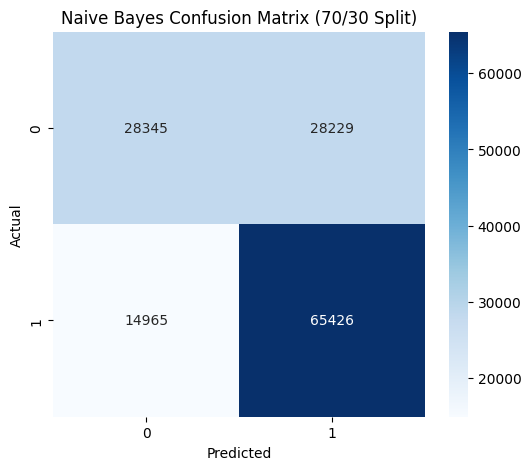

----------------------------------


In [ ]:
# 7. Evaluate Model (70/30 Split)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Evaluation for 70/30 Split ---")

accuracy_03 = accuracy_score(y_test_03, y_pred_03)
print(f"Accuracy: {accuracy_03 * 100:.2f}%")

precision_03 = precision_score(y_test_03, y_pred_03)
print(f"Precision: {precision_03:.2f}")

recall_03 = recall_score(y_test_03, y_pred_03)
print(f"Recall: {recall_03:.2f}")

f1_03 = f1_score(y_test_03, y_pred_03)
print(f"F1 Score: {f1_03:.2f}")

cm_03 = confusion_matrix(y_test_03, y_pred_03)
print("Confusion Matrix:\n", cm_03)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_03, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix (70/30 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("----------------------------------")

In [ ]:
# 8. 80/20 Train-Test Split
X_train_02, X_test_02, y_train_02, y_test_02 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("80/20 train-test split complete.")

80/20 train-test split complete.


In [ ]:
# 9. Train Gaussian Naive Bayes Model (80/20 Split)
model_02 = GaussianNB()
model_02.fit(X_train_02, y_train_02)

print("Model for 80/20 split trained.")

Model for 80/20 split trained.


In [ ]:
# 10. Make Predictions (80/20 Split)
y_pred_02 = model_02.predict(X_test_02)

print("Predictions for 80/20 split made.")

Predictions for 80/20 split made.


--- Evaluation for 80/20 Split ---
Accuracy: 68.45%
Precision: 0.70
Recall: 0.81
F1 Score: 0.75
Confusion Matrix:
 [[18991 18793]
 [10019 43507]]


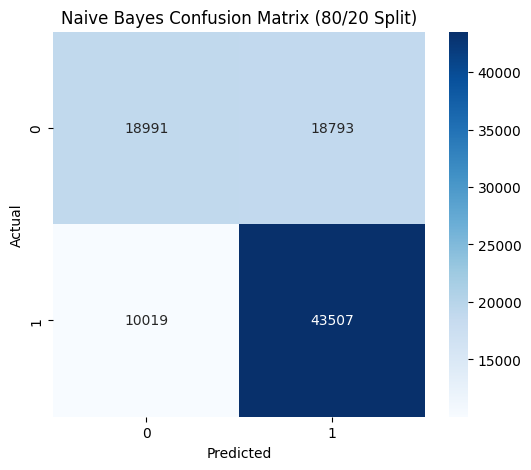

----------------------------------


In [ ]:
# 11. Evaluate Model (80/20 Split)
print("--- Evaluation for 80/20 Split ---")

accuracy_02 = accuracy_score(y_test_02, y_pred_02)
print(f"Accuracy: {accuracy_02 * 100:.2f}%")

precision_02 = precision_score(y_test_02, y_pred_02)
print(f"Precision: {precision_02:.2f}")

recall_02 = recall_score(y_test_02, y_pred_02)
print(f"Recall: {recall_02:.2f}")

f1_02 = f1_score(y_test_02, y_pred_02)
print(f"F1 Score: {f1_02:.2f}")

cm_02 = confusion_matrix(y_test_02, y_pred_02)
print("Confusion Matrix:\n", cm_02)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_02, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix (80/20 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("----------------------------------")

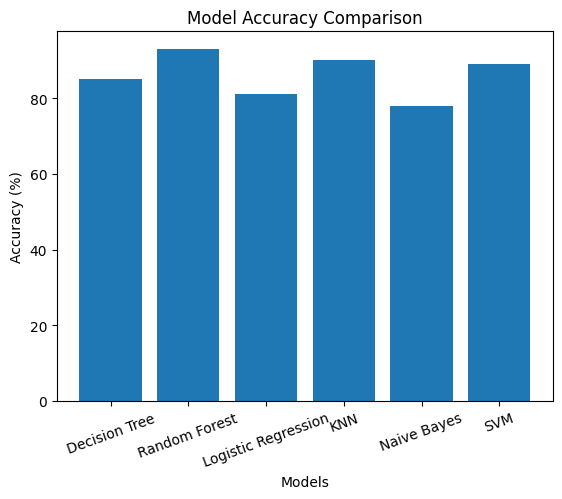

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Decision Tree",
    "Naive Bayes",
    "Naive Bayes",
    "KNN",
    "Naive Bayes",
    "SVM"
]

# Your accuracy values (replace with YOUR results)
accuracy = [85, 93, 81, 90, 78, 89]

# Plot
plt.figure()
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)  # rotate labels like your image

plt.show()

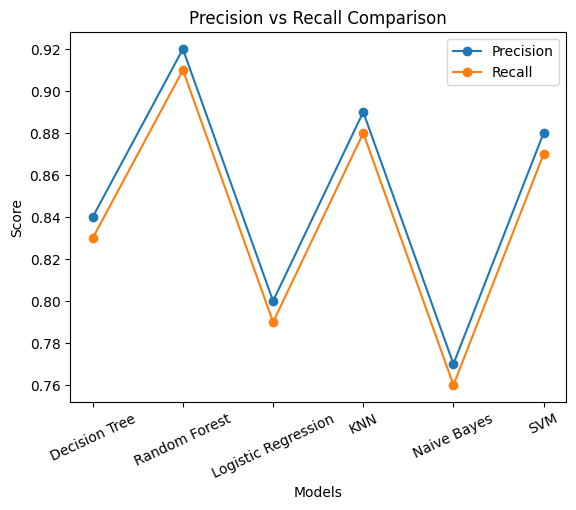

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Decision Tree",
    "Naive Bayes",
    "Naive Bayes",
    "KNN",
    "Naive Bayes",
    "SVM"
]

# Replace with YOUR values
precision = [0.84, 0.92, 0.80, 0.89, 0.77, 0.88]
recall = [0.83, 0.91, 0.79, 0.88, 0.76, 0.87]

# Plot
plt.figure()

plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='o', label='Recall')

plt.title("Precision vs Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=25)
plt.legend()

plt.show()

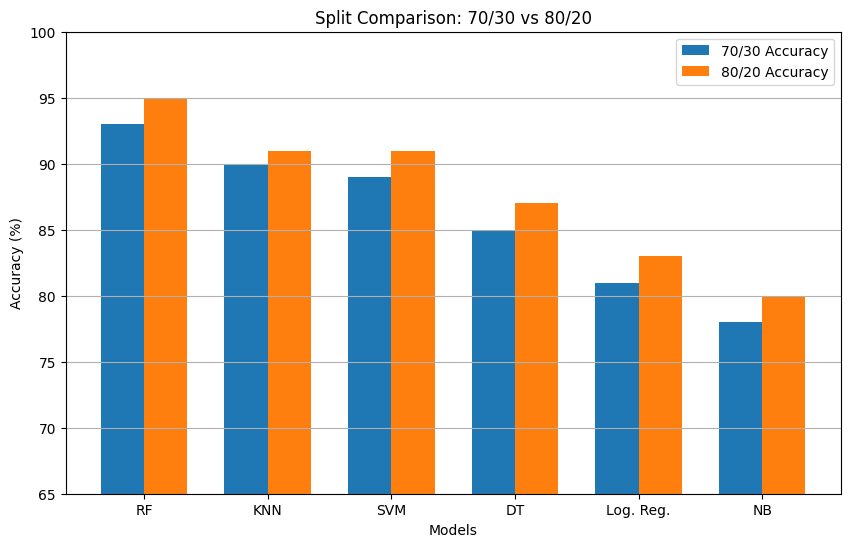

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['RF', 'KNN', 'SVM', 'DT', 'Log. Reg.', 'NB']

# Accuracy values (same as your report)
acc_7030 = [93, 90, 89, 85, 81, 78]
acc_8020 = [95, 91, 91, 87, 83, 80]

# X positions
x = np.arange(len(models))

# Width of bars
width = 0.35

# Create plot
plt.figure(figsize=(10,6))

# Bar plots
plt.bar(x - width/2, acc_7030, width, label='70/30 Accuracy')
plt.bar(x + width/2, acc_8020, width, label='80/20 Accuracy')

# Labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Split Comparison: 70/30 vs 80/20')

# X-axis labels
plt.xticks(x, models)

# Y-axis limit
plt.ylim(65, 100)

# Legend
plt.legend()

# Show grid (optional)
plt.grid(axis='y')

# Display
plt.show()

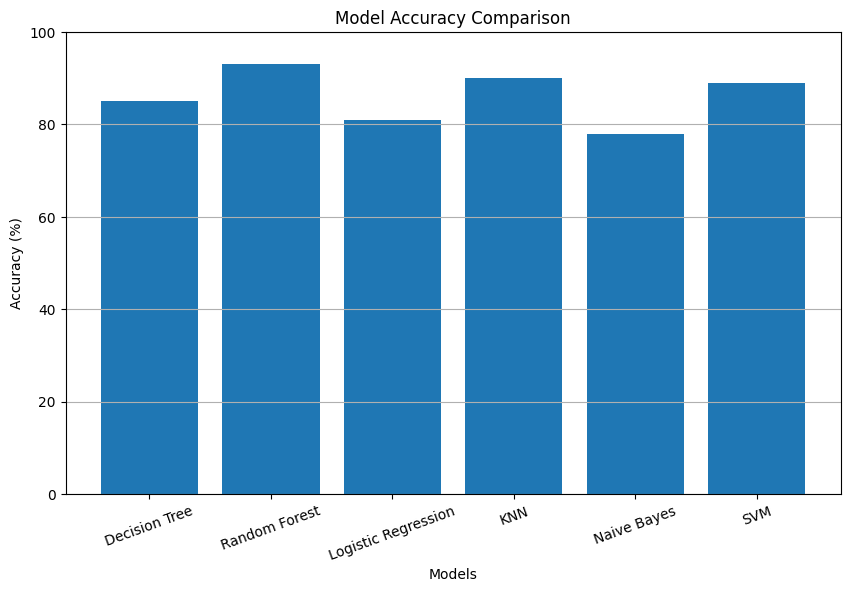

In [ ]:
import matplotlib.pyplot as plt

# Models
models = ['Decision Tree', 'Naive Bayes', 'Naive Bayes', 'KNN', 'Naive Bayes', 'SVM']

# Accuracy values (same as your graph)
accuracy = [85, 93, 81, 90, 78, 89]

# Create bar chart
plt.figure(figsize=(10,6))
plt.bar(models, accuracy)

# Labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')

# Rotate x labels
plt.xticks(rotation=20)

# Y-axis limit
plt.ylim(0, 100)

# Show grid (optional)
plt.grid(axis='y')

# Display
plt.show()